In [30]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


##Анализ оттока клиентов телеком-оператора и разработка стратегии удержания (Retention Strategy)

### 1. Бизнес-контекст и проблематика

Проблема: Телеком-компания сталкивается с оттоком клиентов (Churn). Привлечение нового клиента (CAC) всегда стоит дороже, чем удержание старого.  
Цель проекта:  
1. Провести исследовательский анализ данных (EDA) и выявить сегменты пользователей, наиболее склонных к оттоку.  
2. Построить ML-модель для предсказания вероятности ухода клиента в следующем месяце.  
3. Оценить экономический эффект от внедрения модели и предложить продуктовые решения для удержания.

### 2. Загрузка данных и предобработка

In [1]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 17.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 23.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 29.9MB/s]


In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [3]:
data = pd.read_csv('./train.csv')

**Первая часть. Исследование**

In [4]:
data.sample(7)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
1193,23,19.65,451.55,Female,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,0
1777,16,69.95,1205.5,Male,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),0
3985,3,20.20,50.6,Male,0,No,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),0
3131,30,55.30,1530.6,Female,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),0
2906,11,104.05,1133.65,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),1
3899,16,89.45,1430.25,Female,0,Yes,Yes,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),1
3702,32,30.15,927.65,Female,0,No,No,No,No phone service,DSL,Yes,No,No,No,No,No,One year,No,Mailed check,0


In [47]:
# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [6]:
# Вместо пропусков вставляем 0
data['TotalSpent'] = data['TotalSpent'].replace(' ', 0)
data['TotalSpent'] = data['TotalSpent'].astype(float)

In [7]:
data.isna().sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   float64
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

*Незаполненных значений нет.*

### 3. Продуктовый EDA (Exploratory Data Analysis)

In [9]:
plt.style.use('seaborn-v0_8-pastel')

#### 3.1 Оценка распределения целевой переменной и выбросов у численных признаков

Целевая переменная

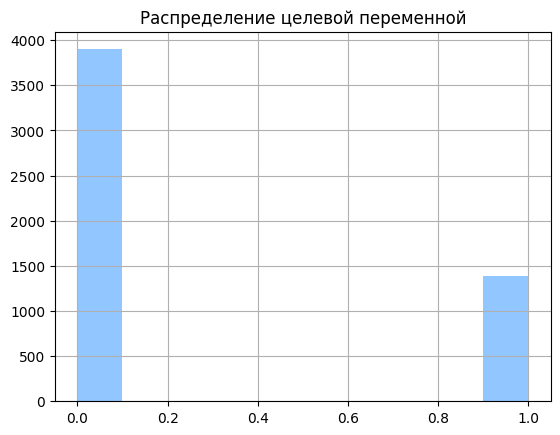

In [10]:
data[target_col].hist()
plt.title('Распределение целевой переменной')
plt.show()

Можем считать переменную сбалансированной

Анализируем численные признаки

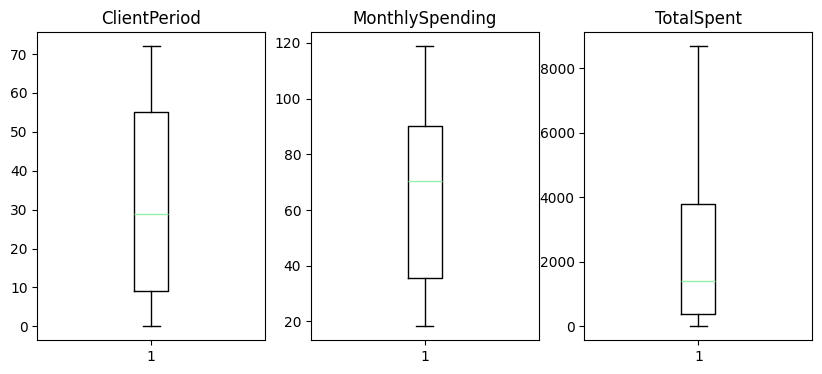

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))

ax1.boxplot(data['ClientPeriod'])
ax2.boxplot(data['MonthlySpending'])
ax3.boxplot(data['TotalSpent'])

ax1.set_title(num_cols[0])
ax2.set_title(num_cols[1])
ax3.set_title(num_cols[2])

plt.show()

*Выбросов нет*

#### 3.2. Анализ ключевых драйверов оттока

Давайте посмотрим, какие услуги или типы контрактов сильнее всего влияют на уход клиентов.

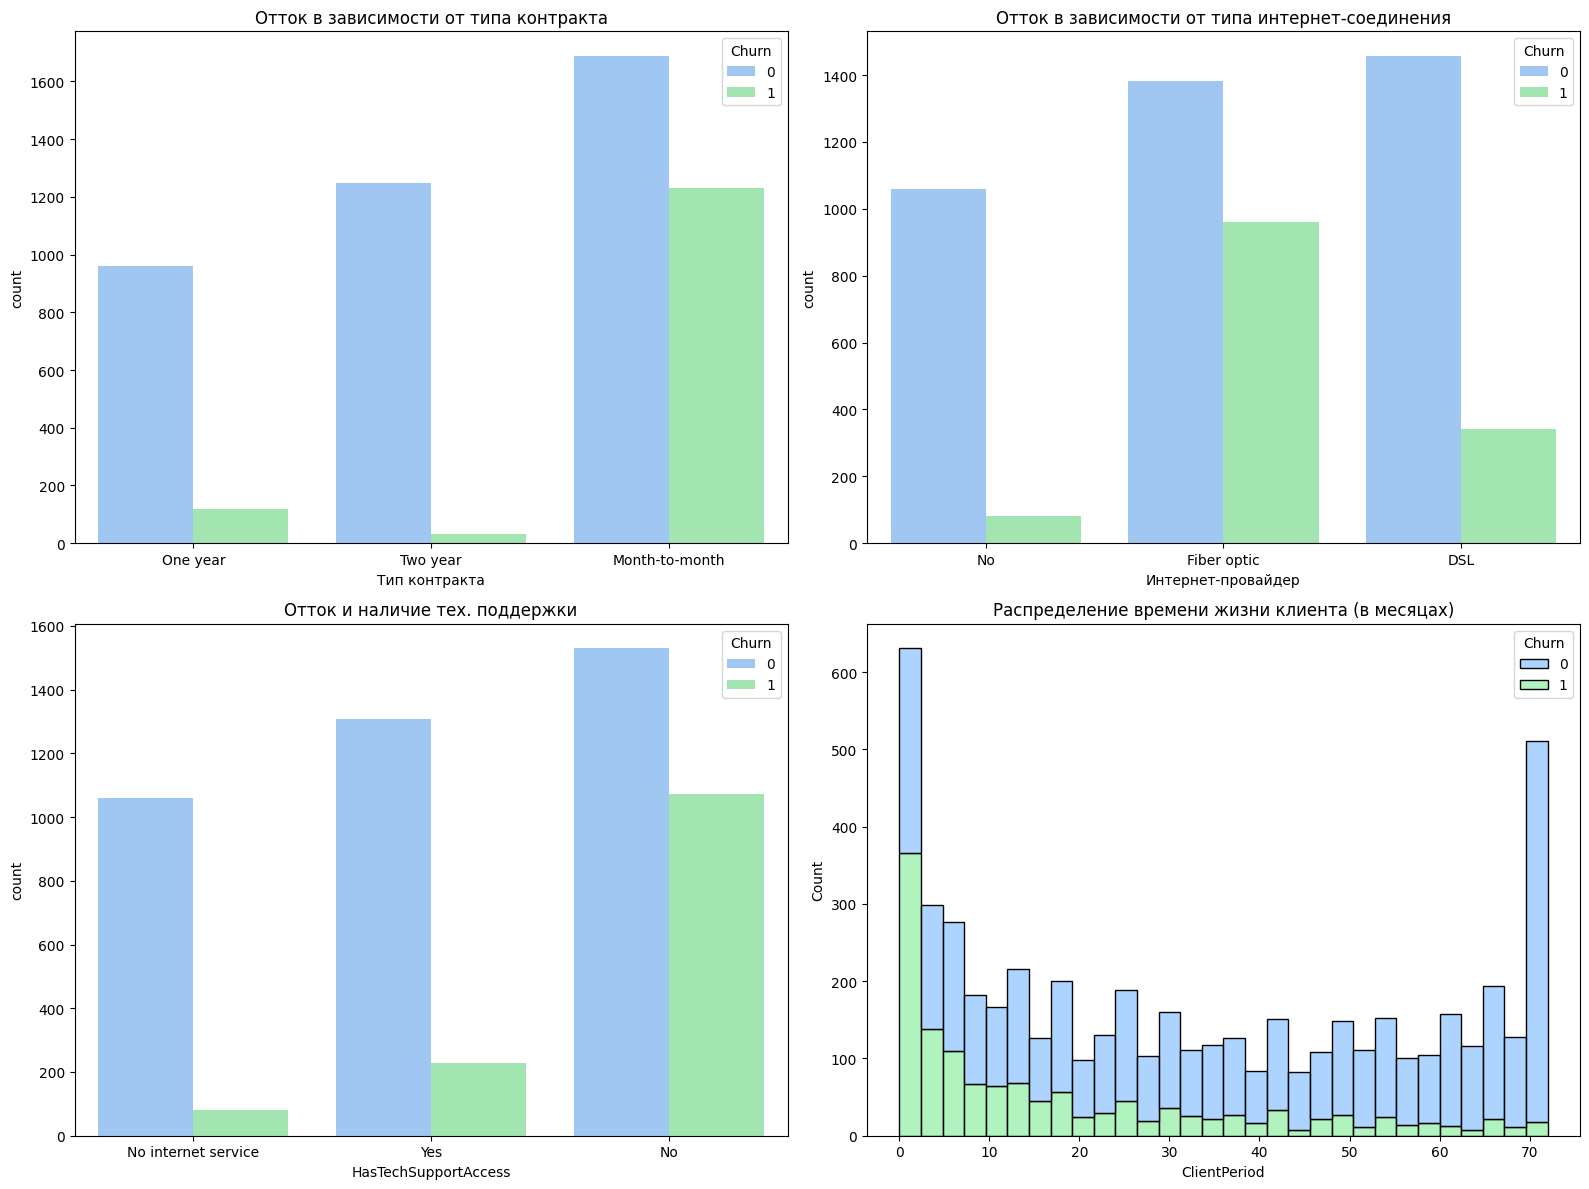

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Отток по типу контракта
sns.countplot(data=data, x='HasContractPhone', hue='Churn', ax=axes[0, 0])
axes[0, 0].set_title('Отток в зависимости от типа контракта')
axes[0, 0].set_xlabel('Тип контракта')

# 2. Отток по типу интернета
sns.countplot(data=data, x='HasInternetService', hue='Churn', ax=axes[0, 1])
axes[0, 1].set_title('Отток в зависимости от типа интернет-соединения')
axes[0, 1].set_xlabel('Интернет-провайдер')

# 3. Отток по наличию техподдержки
sns.countplot(data=data, x='HasTechSupportAccess', hue='Churn', ax=axes[1, 0])
axes[1, 0].set_title('Отток и наличие тех. поддержки')

# 4. Распределение времени жизни клиента (ClientPeriod)
sns.histplot(data=data, x='ClientPeriod', hue='Churn', multiple="stack", bins=30, ax=axes[1, 1])
axes[1, 1].set_title('Распределение времени жизни клиента (в месяцах)')

plt.tight_layout()
plt.show()

Продуктовые выводы из графиков:

* Основной отток происходит среди клиентов с ежемесячной оплатой (Month-to-month). Клиенты с контрактами на 1-2 года практически не уходят.

* Пользователи оптоволокна (Fiber optic) уходят значительно чаще, чем пользователи DSL. Это сигнал для продукта: возможно, оптоволокно работает нестабильно или стоит неоправданно дорого по сравнению с конкурентами.

* Отсутствие технической поддержки коррелирует с высоким оттоком.

* Критический период — первые 1-3 месяца. Если клиент пережил этот этап, вероятность его ухода резко снижается. Нам нужен качественный Onboarding!

### 4. Feature Engineering (Создание новых бизнес-метрик)

In [48]:
# 1. ARPU (Средний чек) = Общие траты / количество месяцев
# Добавляем 1 к ClientPeriod, чтобы избежать деления на 0 для новых клиентов
data['ARPU_calculated'] = data['TotalSpent'] / (data['ClientPeriod'] + 1)

# 2. Категоризация времени жизни клиента (Когорты)
def categorize_tenure(month):
    if month <= 6:
        return '0-6_months (Newbie)'
    elif month <= 24:
        return '6-24_months (Loyal)'
    else:
        return '24+_months (Veteran)'

data['Tenure_Cohort'] = data['ClientPeriod'].apply(categorize_tenure)

cat_cols.append('Tenure_Cohort')
num_cols.append('ARPU_calculated')

### 5. Обучение модели (Logistic Regression, CatBoost)

In [18]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, roc_curve

Применим One hot encoder для категориальных данных

In [20]:
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(data[cat_cols])

one_hot_df = pd.DataFrame(
    one_hot_encoded, columns=encoder.get_feature_names_out(cat_cols), index=data.index
)

In [21]:
# Оставляем только encoded столбцы
df = pd.concat([data, one_hot_df], axis=1)
df = df.drop(cat_cols, axis=1)

df

,ClientPeriod,MonthlySpending,TotalSpent,Churn,ARPU_calculated,Sex_Female,Sex_Male,IsSeniorCitizen_0,IsSeniorCitizen_1,HasPartner_No,...,HasContractPhone_Two year,IsBillingPaperless_No,IsBillingPaperless_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Cohort_0-6_months (Newbie),Tenure_Cohort_24+_months (Veteran),Tenure_Cohort_6-24_months (Loyal)
0,55,19.50,1026.35,0,18.327679,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,72,25.85,1872.20,0,25.646575,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1,75.90,75.90,1,37.950000,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,32,79.30,2570.00,0,77.878788,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,60,115.25,6758.45,0,110.794262,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5277,3,30.40,82.15,0,20.537500,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
5278,50,44.45,2188.45,0,42.910784,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5279,1,55.05,55.05,0,27.525000,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
5280,29,76.00,2215.25,0,73.841667,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


Получаем матрицы X, y. Разделяем на обучающую и тестовую. Нормируем.

In [22]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values,
                                                    train_size=0.8,
                                                    random_state=42)

In [24]:
# Нормируем данные строго после train_test_split, чтобы избежать подглядывания
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##**LogisticRegression**

In [25]:
param_c = [100, 10, 1, 0.1, 0.01, 0.001]

model = LogisticRegressionCV(Cs=param_c, n_jobs=-1, scoring='roc_auc', refit=True)

model.fit(X_train_scaled, y_train)

LogisticRegressionCV(Cs=[100, 10, 1, 0.1, 0.01, 0.001], n_jobs=-1,
                     scoring='roc_auc')

In [28]:
y_pred = model.predict_proba(X_test_scaled)[:, 1]
LR_roc_auc_sc = roc_auc_score(y_test, y_pred)
print(f"Полученный результат roc_auc_score у LogisticRegression = {LR_roc_auc_sc:.4f}")

Полученный результат roc_auc_score у LogisticRegression = 0.8301


##**Градиентный бустинг**

In [31]:
from catboost import CatBoostClassifier

In [49]:
# CatBoost хорошо "под капотом" обрабатывает категориальные данные

X = data.drop(['Churn'], axis=1)
y = data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [50]:
# boosting_model = CatBoostClassifier()
boosting_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=False # Отключаем вывод простыни логов обучения
)
boosting_model.fit(X_train, y_train, cat_features=cat_cols)

y_train_predicted = boosting_model.predict_proba(X_train)[:, 1]
y_test_predicted = boosting_model.predict_proba(X_test)[:, 1]

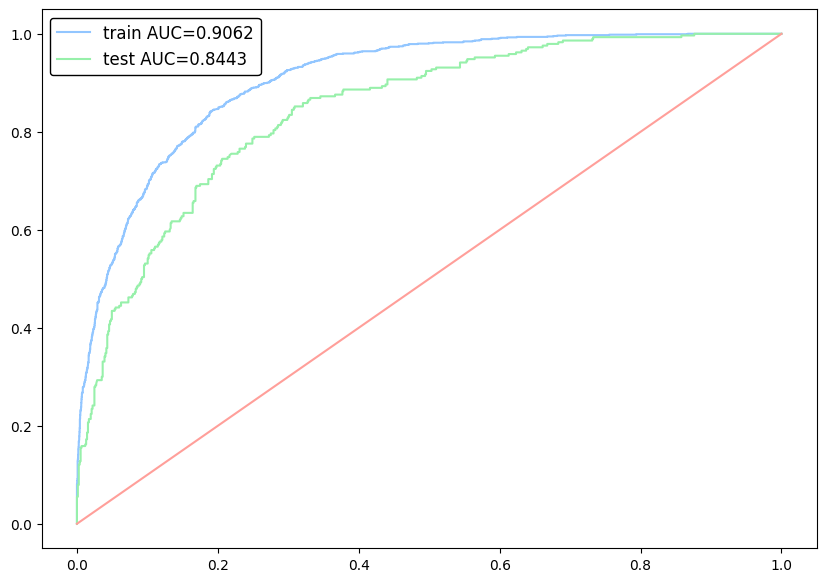

In [51]:
train_auc = roc_auc_score(y_train, y_train_predicted)
test_auc = roc_auc_score(y_test, y_test_predicted)

plt.figure(figsize=(10,7))
plt.plot(*roc_curve(y_train, y_train_predicted)[:2], label='train AUC={:.4f}'.format(train_auc))
plt.plot(*roc_curve(y_test, y_test_predicted)[:2], label='test AUC={:.4f}'.format(test_auc))
legend_box = plt.legend(fontsize='large', framealpha=1).get_frame()
legend_box.set_facecolor("white")
legend_box.set_edgecolor("black")
plt.plot(np.linspace(0,1,100), np.linspace(0,1,100))
plt.show()

Лучший результат у модели CatBoost: 0.8443

### 6. Интерпретация модели (SHAP Values)

In [39]:
import shap

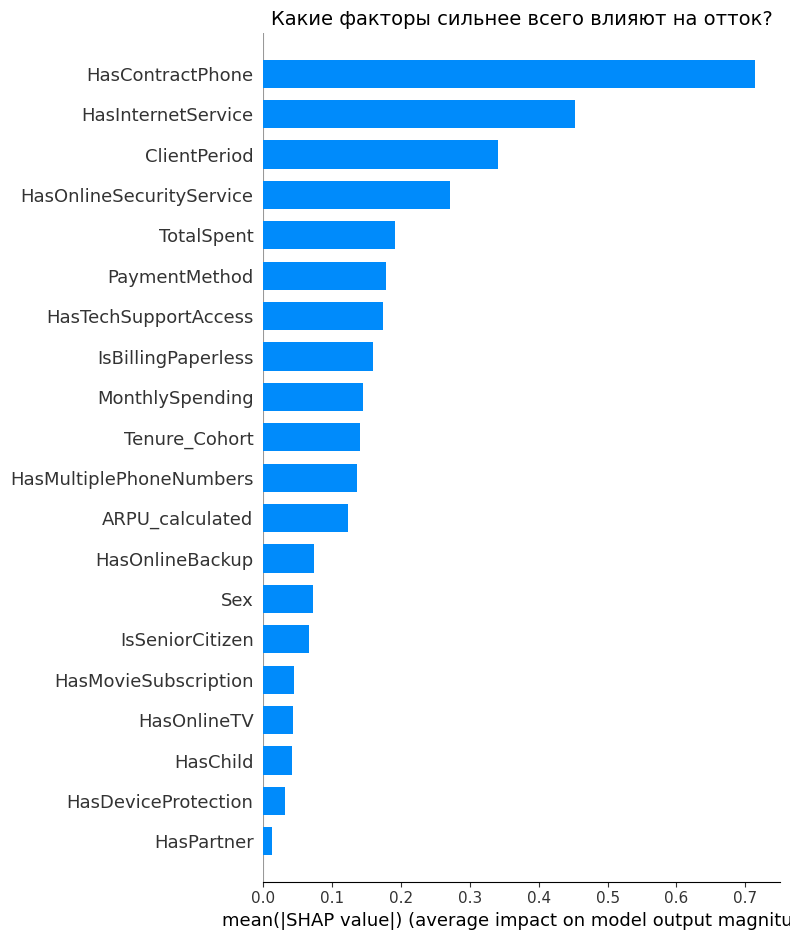

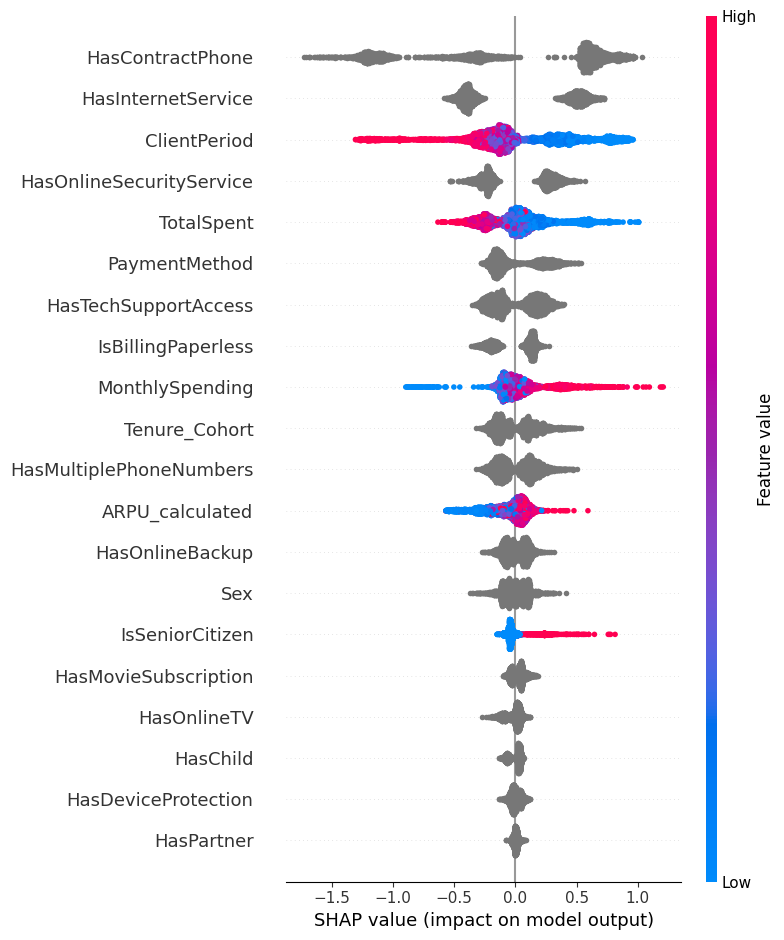

In [52]:
explainer = shap.TreeExplainer(boosting_model)
shap_values = explainer.shap_values(X_train)

# Строим график влияния признаков
plt.title('Какие факторы сильнее всего влияют на отток?', fontsize=14)
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.show()

# Более детальный график (пчелиный рой)
shap.summary_plot(shap_values, X_train)


Анализ факторов:

* ClientPeriod: чем меньше месяцев с нами, тем выше шанс оттока.

* HasContractPhone (тип контракта) - Month-to-month сильно толкает скор в сторону ухода.

* MonthlySpending: высокие ежемесячные платежи провоцируют уход.

### 7. Экономика продукта (Бизнес-эффект от модели)

Сделаем расчет порога, при какой вероятности ухода нам выгодно предлагать клиенту скидку.

In [53]:
from sklearn.metrics import confusion_matrix

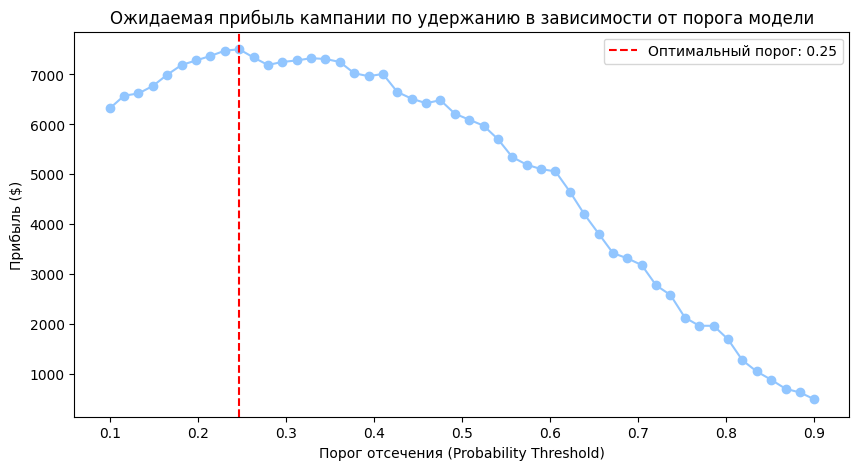

Оптимальный порог вероятности для выдачи скидки: 0.25
Максимальная сохраненная выручка на тестовой выборке: $7500


In [54]:
# Получаем вероятности оттока на тестовой выборке
y_pred_proba = boosting_model.predict_proba(X_test)[:, 1]

# --- ФИНАНСОВАЯ МОДЕЛЬ (Условные цифры) ---
# Допустим, ARPU (доход с клиента) = $60
# Затраты на удержание (скидка/бонус) = $15
# Если клиент уходит, мы теряем $60. Если удерживаем - спасаем $45 ($60 - $15).

profit_per_retained_user = 45  # Доход с сохраненного клиента (True Positive)
cost_per_wasted_offer = -15    # Убыток, если дали скидку тому, кто и так бы остался (False Positive)

profits = []
thresholds = np.linspace(0.1, 0.9, 50)

# Ищем идеальный порог вероятности для предложения скидки
for thresh in thresholds:
    y_pred_custom = (y_pred_proba >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_custom)

    # cm[1,1] - True Positives (правильно поймали уходящих, предложили бонус, они остались)
    # cm[0,1] - False Positives (ошиблись, дали скидку лояльным - потеряли деньги)

    profit = (cm[1, 1] * profit_per_retained_user) + (cm[0, 1] * cost_per_wasted_offer)
    profits.append(profit)

best_thresh = thresholds[np.argmax(profits)]
max_profit = max(profits)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, profits, marker='o')
plt.axvline(x=best_thresh, color='r', linestyle='--', label=f'Оптимальный порог: {best_thresh:.2f}')
plt.title('Ожидаемая прибыль кампании по удержанию в зависимости от порога модели')
plt.xlabel('Порог отсечения (Probability Threshold)')
plt.ylabel('Прибыль ($)')
plt.legend()
plt.show()

print(f"Оптимальный порог вероятности для выдачи скидки: {best_thresh:.2f}")
print(f"Максимальная сохраненная выручка на тестовой выборке: ${max_profit}")


Возникает вопрос: Почему порог такой низкий (~0.25)?

Математически, точка безубыточности достигается, когда вероятность ухода составляет 25%. Формула: $0.25 \times \$45 (\text{спасенные деньги}) - 0.75 \times \$15 (\text{зря розданная скидка}) = 0$ (еще мы опустили издержки, которые пойдут на удержанных клиентов помимо скидки). То есть, алгоритму "выгодно" закидывать скидками даже тех, кто сомневается лишь на четверть.

Но здесь кроется бизнес-подвох (Каннибализация выручки):
Если мы будем давать скидку при пороге 0.25, мы раздадим её огромному числу лояльных клиентов (75% из них не собирались уходить). Это приведет к тому, что:

* Клиенты привыкнут к постоянным скидкам ("Discount hunting").

* Мы обрушим общий ARPU компании в долгосрочной перспективе.

**Решение**: В реальном бизнесе математический порог (0.25) корректируется стратегическими ограничениями. Мы повысим порог выдачи денежной скидки до 0.60 - 0.70, чтобы таргетировать только "красную зону". А для клиентов с вероятностью 0.30 - 0.60 будем применять бесплатные методы удержания (звонок от службы заботы, бесплатный аудит роутера, email-рассылка с полезными фичами).

### 8. Итоговые рекомендации для бизнеса (Conclusion)

Основываясь на данных и построенной модели, предлагается следующая стратегия удержания:

1. Многоуровневая кампания удержания:

* Скор > 0.65 (High Risk): Предлагаем скидку 20% на следующий месяц.

* Скор 0.35 - 0.65 (Medium Risk): Инициируем звонок саппорта для проверки удовлетворенности (особенно для пользователей Fiber Optic).

2. Фокус на новичках: Настроить триггерную рассылку и звонки от саппорта для клиентов на тарифе "Month-to-month" в первые 3 месяца их жизни.

3. Аудит услуги Fiber Optic: Передать данные в технический отдел для проверки качества оптоволоконного интернета, так как этот сегмент показывает аномально высокий Churn rate.